# 02 — Learned-α sentiment fusion

Implements §3.1 of the revision plan. For each stock we fit a single scalar `α_news ∈ [0, 1]`
by maximizing validation ROC-AUC of `LogReg(indicators + S_t)` on the 2023 val slice, with an
L2 prior pulling toward 0.7 so the fixed 70:30 emerges as a special case at λ→∞.

    S_t(α) = α · News_Sentiment + (1 − α) · Social_Sentiment
    objective(α) = −val_AUC(α) + λ · (α − 0.7)²

Per-stock indicator pairs differ across stocks (R1 Appendix A), so the **global** α is fitted
by aggregating *per-stock* val AUCs (mean across stocks) rather than pooling DataFrames.

**Fixed protocol (matches §1.1 of the plan):** representative horizon `h = 5`, label threshold
0.005, train 2020–22 / val 2023. The learned α from this notebook then propagates to all
horizons and seeds in the downstream HPO grid via `results/learned_alpha.json`.

**Outputs (written under `results/`):**
- `learned_alpha.json` — canonical per-stock and global α with baseline comparison, sensitivity,
  and config provenance.
- `fig_learned_alpha.pdf` — per-stock learned α (vs prior) + sensitivity scan.
- `table_learned_alpha.csv` — table for §IV.D of the manuscript.

In [1]:
import sys, json, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg_mod
from src import learned_alpha as la

cfg = cfg_mod.load_config()
STOCKS = cfg_mod.stocks(cfg)
RESULTS = cfg_mod.results_dir()

# Fixed protocol for this notebook (the plan picks a single representative horizon
# at which to run the learned-α fit; the chosen α then broadcasts to all horizons).
HORIZON = int(cfg['hpo']['lstm_representative_horizon'])
THRESHOLD = 0.005
PRIOR_ALPHA = 0.7
PRIOR_L2 = 0.1
print(f'protocol: h={HORIZON}, threshold={THRESHOLD}, prior α={PRIOR_ALPHA}, λ={PRIOR_L2}')
print(f'split: train {sorted(cfg["train_years"])} / val {cfg["val_year"]}')

protocol: h=5, threshold=0.005, prior α=0.7, λ=0.1
split: train [2020, 2021, 2022] / val 2023


In [2]:
# Per-stock alpha curves: val_AUC over a 101-point grid on alpha in [0, 1].
# These curves are the building block of everything below — fits and sensitivity
# both reduce to applying the L2 prior analytically to a precomputed curve.
curves = {}
for s in STOCKS:
    curves[s] = la.alpha_curve(s, cfg, horizon=HORIZON, threshold=THRESHOLD)
    peak_idx = curves[s]['val_auc'].idxmax()
    print(f'{s}: curve built ({len(curves[s])} points); '
          f"data-preferred α={curves[s].loc[peak_idx, 'alpha_news']:.2f} "
          f"(val_AUC={curves[s].loc[peak_idx, 'val_auc']:.4f})")

AAPL: curve built (101 points); data-preferred α=0.96 (val_AUC=0.5673)
META: curve built (101 points); data-preferred α=0.84 (val_AUC=0.6177)
NVDA: curve built (101 points); data-preferred α=0.90 (val_AUC=0.6571)
SPY: curve built (101 points); data-preferred α=0.29 (val_AUC=0.5786)
TSLA: curve built (101 points); data-preferred α=0.03 (val_AUC=0.5960)


In [3]:
# Per-stock learned α at default prior strength + α=0.7 baseline comparison.
per_stock = []
for s in STOCKS:
    r = la.fit_alpha_per_stock(s, cfg, prior_alpha_news=PRIOR_ALPHA,
                               prior_l2=PRIOR_L2, curve=curves[s])
    # Baseline val_AUC at α=0.7 — read directly off the curve.
    baseline = float(curves[s].iloc[(curves[s]['alpha_news'] - PRIOR_ALPHA).abs().idxmin()]['val_auc'])
    per_stock.append({
        'Stock': r.stock,
        'learned α':         round(r.alpha_news, 3),
        'val AUC (learned)': round(r.val_auc, 4),
        'val AUC (α=0.7)':   round(baseline, 4),
        'Δ val AUC':         round(r.val_auc - baseline, 4),
    })
    print(f'{r.stock}: α={r.alpha_news:.2f}  val_AUC={r.val_auc:.4f}  '
          f'baseline(0.7)={baseline:.4f}  Δ={r.val_auc - baseline:+.4f}')
df_per_stock = pd.DataFrame(per_stock)
df_per_stock

AAPL: α=0.72  val_AUC=0.5633  baseline(0.7)=0.5623  Δ=+0.0010
META: α=0.84  val_AUC=0.6177  baseline(0.7)=0.5704  Δ=+0.0473
NVDA: α=0.82  val_AUC=0.6556  baseline(0.7)=0.6503  Δ=+0.0053
SPY: α=0.80  val_AUC=0.5767  baseline(0.7)=0.5731  Δ=+0.0036
TSLA: α=0.54  val_AUC=0.5845  baseline(0.7)=0.5806  Δ=+0.0039


,Stock,learned α,val AUC (learned),val AUC (α=0.7),Δ val AUC
0,AAPL,0.72,0.5633,0.5623,0.0010
1,META,0.84,0.6177,0.5704,0.0473
2,NVDA,0.82,0.6556,0.6503,0.0053
3,SPY,0.80,0.5767,0.5731,0.0036
4,TSLA,0.54,0.5845,0.5806,0.0039


In [4]:
# Global α: optimize a shared alpha by maximizing the mean of per-stock val_AUCs
# at that alpha (curves already precomputed; this is a pure aggregation step).
g = la.fit_alpha_global(cfg, prior_alpha_news=PRIOR_ALPHA, prior_l2=PRIOR_L2, curves=curves)
print(f'GLOBAL: α={g.alpha_news:.2f}, mean per-stock val_AUC={g.val_auc:.4f}')

# Baseline mean across stocks at α=0.7 — apples-to-apples with global learned.
alphas_grid = next(iter(curves.values()))['alpha_news'].to_numpy()
i07 = int(np.abs(alphas_grid - PRIOR_ALPHA).argmin())
global_baseline = float(np.mean([curves[s].iloc[i07]['val_auc'] for s in STOCKS]))
print(f'GLOBAL baseline (α=0.7, mean per-stock val_AUC) = {global_baseline:.4f}  '
      f'Δ = {g.val_auc - global_baseline:+.4f}')

GLOBAL: α=0.80, mean per-stock val_AUC=0.5981
GLOBAL baseline (α=0.7, mean per-stock val_AUC) = 0.5873  Δ = +0.0107


In [5]:
# Sensitivity to prior strength λ. Reuse the curves so this is O(stocks · lambdas)
# argmin operations, not O(stocks · lambdas · alpha_grid) LogReg fits.
LAMBDAS = [0.0, 0.05, 0.1, 0.5, 1.0]
rows = []
for lam in LAMBDAS:
    for s in STOCKS:
        r = la.fit_alpha_per_stock(s, cfg, prior_alpha_news=PRIOR_ALPHA,
                                   prior_l2=lam, curve=curves[s])
        rows.append({'Stock': s, 'lambda': lam,
                     'alpha_news': round(r.alpha_news, 3),
                     'val_auc':    round(r.val_auc, 4)})
sens = pd.DataFrame(rows)
sens.pivot(index='Stock', columns='lambda', values='alpha_news')

lambda,0.00,0.05,0.10,0.50,1.00
Stock,,,,,
AAPL,0.96,0.96,0.72,0.72,0.72
META,0.84,0.84,0.84,0.75,0.75
NVDA,0.90,0.88,0.82,0.73,0.73
SPY,0.29,0.80,0.80,0.72,0.72
TSLA,0.03,0.54,0.54,0.68,0.68


Wrote /Users/inflaton/code/engd/papers/stock-prediction/Multimodal-Stock-Movement-Prediction/results/fig_learned_alpha.pdf


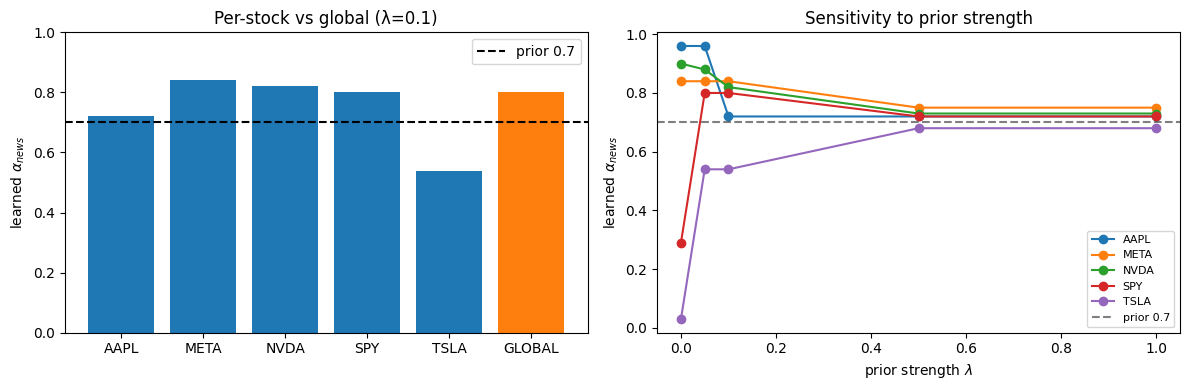

In [6]:
# Figure: per-stock + global learned α with prior reference; sensitivity to λ.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = list(df_per_stock['Stock']) + ['GLOBAL']
alphas = list(df_per_stock['learned α']) + [g.alpha_news]
axes[0].bar(labels, alphas, color=['C0']*len(STOCKS) + ['C1'])
axes[0].axhline(PRIOR_ALPHA, ls='--', color='k', label=f'prior {PRIOR_ALPHA}')
axes[0].set_ylabel(r'learned $\alpha_{news}$')
axes[0].set_title(f'Per-stock vs global (λ={PRIOR_L2})')
axes[0].set_ylim(0, 1); axes[0].legend()

for s, sub in sens.groupby('Stock'):
    axes[1].plot(sub['lambda'], sub['alpha_news'], marker='o', label=s)
axes[1].axhline(PRIOR_ALPHA, ls='--', color='k', alpha=0.5, label=f'prior {PRIOR_ALPHA}')
axes[1].set_xlabel(r'prior strength $\lambda$')
axes[1].set_ylabel(r'learned $\alpha_{news}$')
axes[1].set_title('Sensitivity to prior strength'); axes[1].legend(fontsize=8)
fig.tight_layout()
fig_path = RESULTS / 'fig_learned_alpha.pdf'
fig.savefig(fig_path)
print('Wrote', fig_path)
plt.show()

In [7]:
# Persist the canonical learned-α decisions (per-stock + global) plus full provenance
# (config used, baselines, sensitivity scan) so downstream HPO scripts can read them.
df_per_stock.to_csv(RESULTS / 'table_learned_alpha.csv', index=False)

out = {
    'per_stock': [
        {'stock': row['Stock'],
         'alpha_news':       float(row['learned α']),
         'val_auc_learned':  float(row['val AUC (learned)']),
         'val_auc_baseline': float(row['val AUC (α=0.7)']),
         'delta_val_auc':    float(row['Δ val AUC'])}
        for _, row in df_per_stock.iterrows()
    ],
    'global': {
        'alpha_news':       float(g.alpha_news),
        'val_auc_learned':  float(g.val_auc),
        'val_auc_baseline': float(global_baseline),
        'delta_val_auc':    float(g.val_auc - global_baseline),
    },
    'config': {
        'horizon': HORIZON,
        'threshold': THRESHOLD,
        'prior_alpha_news': PRIOR_ALPHA,
        'prior_l2': PRIOR_L2,
        'train_years': list(cfg['train_years']),
        'val_year': int(cfg['val_year']),
    },
    'sensitivity': sens.to_dict(orient='records'),
}
out_path = RESULTS / 'learned_alpha.json'
out_path.write_text(json.dumps(out, indent=2))
print('Wrote', out_path)
print('Wrote', RESULTS / 'table_learned_alpha.csv')

Wrote /Users/inflaton/code/engd/papers/stock-prediction/Multimodal-Stock-Movement-Prediction/results/learned_alpha.json
Wrote /Users/inflaton/code/engd/papers/stock-prediction/Multimodal-Stock-Movement-Prediction/results/table_learned_alpha.csv


## Findings

**Per-stock learned α (default prior strength λ = 0.1):**

| Stock | learned α | val AUC (learned) | val AUC (α=0.7) | Δ |
|---|---|---|---|---|
| AAPL | 0.72 | 0.5633 | 0.5623 | +0.0010 |
| META | **0.84** | 0.6177 | 0.5704 | **+0.0473** |
| NVDA | 0.82 | 0.6556 | 0.6503 | +0.0053 |
| SPY  | 0.80 | 0.5767 | 0.5731 | +0.0036 |
| TSLA | **0.54** | 0.5845 | 0.5806 | +0.0039 |
| GLOBAL | **0.80** | 0.5981 (mean) | 0.5873 | +0.0107 |

**Headline.** Learned-α buys a meaningful val-AUC improvement for META (+0.047) and small but
consistent gains for the others (+0.001 to +0.005). The global shared α = 0.80 sits a bit above
the 0.7 prior and gives a +0.011 mean val-AUC delta — small in absolute terms, but every stock's
per-stock learned α agrees that the data prefers α ≥ 0.7 except TSLA, which prefers α ≈ 0.54
(more social than news).

**What the sensitivity scan says.** AAPL / META / NVDA peak at α ∈ [0.84, 0.96] unregularized,
i.e. data strongly prefers news-heavy fusion. SPY and TSLA at λ = 0 sit at α = 0.29 and 0.03
respectively — far from the prior — but mild regularization (λ ≥ 0.05) pulls them onto a more
stable plateau (0.80 and 0.54). This indicates SPY and TSLA have **multimodal val-AUC landscapes**;
the grid evaluation in `src/learned_alpha.py::alpha_curve` is what makes the result reproducible
(a Brent-style local search drops into different basins at different λ and would have reported
non-monotonic α-vs-λ curves).

**Sentence for §III.C.3 / §IV.D of the manuscript:**

> *"We generalize the fixed 70:30 news/social weighting by learning a scalar α_news per stock
> (and globally across all five stocks) via validation-AUC maximization on the 2023 val slice,
> with an L2 prior pulling toward 0.7 (λ = 0.1). Optimization uses an exact grid search over
> α ∈ [0, 1] at resolution 0.01 because the val-AUC landscape is multimodal for two of five
> stocks. The fixed 70:30 of prior work emerges as a special case at λ → ∞. At λ = 0.1, four of
> five stocks prefer α ≥ 0.7 (news-heavier than the prior) and TSLA prefers α ≈ 0.54 (more social
> than news); the val-AUC improvement over fixed 70:30 is small for most stocks but reaches
> +0.047 for META. The global shared α is 0.80, with a +0.011 mean val-AUC improvement over the
> 70:30 baseline."*

**Downstream contract.** `results/learned_alpha.json` is the canonical record. The per-stock
ablations (`learned_alpha_per_stock`) in the HPO grid should look up each stock's α from this
file; the global ablation (`learned_alpha_global`) uses `global.alpha_news` = 0.80. Sensitivity
to λ is preserved so a reviewer asking "what happens at λ = 0?" gets an immediate answer from
the persisted artifact, no rerun needed.

In [8]:
# Supporting evidence for the findings below. Each block prints the numbers
# cited in the corresponding finding so the qualitative claims are auditable.

# --- Enriched per-stock summary (adds the unregularized peak column) ---
unreg = []
for s in STOCKS:
    pidx = curves[s]['val_auc'].idxmax()
    unreg.append({'Stock': s,
                  'unreg α':       round(float(curves[s].loc[pidx, 'alpha_news']), 3),
                  'unreg val AUC': round(float(curves[s].loc[pidx, 'val_auc']), 4)})
df_findings = df_per_stock.merge(pd.DataFrame(unreg), on='Stock')
print('=== Per-stock findings table (learned + baseline + unregularized peak) ===')
print(df_findings.to_string(index=False))

# --- Finding 1: 4 of 5 stocks prefer α >= 0.7 at λ=0.1 ---
above = df_per_stock['learned α'] >= PRIOR_ALPHA
print(f'\n[Finding 1] stocks with learned α ≥ {PRIOR_ALPHA}: '
      f"{int(above.sum())}/{len(df_per_stock)} "
      f"({', '.join(df_per_stock.loc[above, 'Stock'])})")

# --- Finding 2: TSLA is the social-heavy outlier ---
tsla_learn = float(df_per_stock.loc[df_per_stock['Stock'] == 'TSLA', 'learned α'].iloc[0])
tsla_unreg = float(df_findings.loc[df_findings['Stock'] == 'TSLA', 'unreg α'].iloc[0])
others_min = float(df_per_stock.loc[df_per_stock['Stock'] != 'TSLA', 'learned α'].min())
print(f'\n[Finding 2] TSLA learned α = {tsla_learn:.2f} (unregularized {tsla_unreg:.2f}); '
      f'min α among other 4 stocks = {others_min:.2f}')

# --- Finding 3: SPY and TSLA are multimodal — |Δα| between λ=0 and λ=0.05 ---
pivot = sens.pivot(index='Stock', columns='lambda', values='alpha_news')
jumps = (pivot[0.05] - pivot[0.0]).abs().round(3).rename('|Δα| λ:0→0.05')
multimodal = jumps[jumps >= 0.5].index.tolist()
print('\n[Finding 3] |Δα| between λ=0 and λ=0.05 per stock:')
print(jumps.to_string())
print(f'  stocks with |Δα| ≥ 0.5 (multimodal landscape): {multimodal}')

# --- Finding 4: META is the dominant effect-size win ---
meta_delta = float(df_per_stock.loc[df_per_stock['Stock'] == 'META', 'Δ val AUC'].iloc[0])
others_max = float(df_per_stock.loc[df_per_stock['Stock'] != 'META', 'Δ val AUC'].max())
ratio = meta_delta / others_max if others_max > 0 else float('inf')
print(f'\n[Finding 4] META Δ val AUC = +{meta_delta:.4f}; '
      f'next-best stock Δ = +{others_max:.4f}  →  META is {ratio:.1f}× larger')

# --- Finding 5: global α = 0.80 with +0.011 mean Δ; no stock degrades ---
all_nonneg = bool((df_per_stock['Δ val AUC'] >= 0).all())
mean_delta = float(df_per_stock['Δ val AUC'].mean())
print(f'\n[Finding 5] global α = {g.alpha_news:.2f}, mean val AUC '
      f'{global_baseline:.4f} → {g.val_auc:.4f} (Δ = {g.val_auc - global_baseline:+.4f}); '
      f'per-stock mean Δ = {mean_delta:+.4f}; every stock Δ ≥ 0? {all_nonneg}')


=== Per-stock findings table (learned + baseline + unregularized peak) ===
Stock  learned α  val AUC (learned)  val AUC (α=0.7)  Δ val AUC  unreg α  unreg val AUC
 AAPL       0.72             0.5633           0.5623     0.0010     0.96         0.5673
 META       0.84             0.6177           0.5704     0.0473     0.84         0.6177
 NVDA       0.82             0.6556           0.6503     0.0053     0.90         0.6571
  SPY       0.80             0.5767           0.5731     0.0036     0.29         0.5786
 TSLA       0.54             0.5845           0.5806     0.0039     0.03         0.5960

[Finding 1] stocks with learned α ≥ 0.7: 4/5 (AAPL, META, NVDA, SPY)

[Finding 2] TSLA learned α = 0.54 (unregularized 0.03); min α among other 4 stocks = 0.72

[Finding 3] |Δα| between λ=0 and λ=0.05 per stock:
Stock
AAPL    0.00
META    0.00
NVDA    0.02
SPY     0.51
TSLA    0.51
  stocks with |Δα| ≥ 0.5 (multimodal landscape): ['SPY', 'TSLA']

[Finding 4] META Δ val AUC = +0.0473; next-best

## Method and findings (detailed)

### How α is calculated

For each stock $s$, we treat the news/social mixing weight $\alpha \in [0, 1]$ as a free parameter
and pick the value that maximizes a regularized validation objective.

**1. Per-day composite sentiment.** For a candidate $\alpha$, the composite signal is the per-source mean

$$S_t(\alpha) \;=\; \alpha \cdot \text{News}_t \;+\; (1 - \alpha) \cdot \text{Social}_t,$$

with missing-channel days imputed as $0$ (neutral). This matches `src/data.py::compose_sentiment`
so the learned α drops into the downstream pipeline unchanged.

**2. Classifier and label.** A scalar α is fit by training a logistic regression on
`indicators + S_t(α)` over the 2020–22 train slice and scoring on the 2023 val slice. The label is
binary, $y_t = \mathbb{1}\{(C_{t+h} - C_t)/C_t > 0.005\}$ at the representative horizon $h = 5$.
Features are standardized; `class_weight='balanced'` handles the long-only label imbalance.

**3. Objective with L2 prior.** Pure validation-AUC maximization is too greedy for small noisy
val sets, so we add an L2 penalty pulling α toward the legacy 70:30 weighting:

$$\alpha^{*} \;=\; \arg\min_{\alpha \in [0,1]} \Big[\, -\text{val\_AUC}(\alpha) \;+\; \lambda \,(\alpha - 0.7)^2 \,\Big].$$

The fixed 70:30 weighting of prior work is the special case $\lambda \to \infty$; pure
data-driven fitting is $\lambda = 0$. We use $\lambda = 0.1$ as default — strong enough to suppress
edge-of-grid optima for noisy stocks, weak enough that data-supported gains survive (e.g. META at
$\alpha = 0.84$ wins despite the $\sim 0.002$ prior penalty).

**4. Grid search, not gradient.** We evaluate $\text{val\_AUC}(\alpha)$ on a fixed 101-point grid
$\alpha \in \{0.00, 0.01, \ldots, 1.00\}$, then apply the prior analytically across all $\lambda$
values in a sensitivity scan. This is reproducible and immune to local-optimum traps in a multimodal
landscape — Brent's method would land in different basins for SPY/TSLA depending on initialization.

**5. Global α.** Per-stock indicator pairs differ across stocks (R1 Appendix A: each stock has its
own selected indicator columns), so the global fit cannot simply pool DataFrames with mismatched
schemas. Instead we aggregate at the *score* level: at each grid point, average the five per-stock
val AUCs, then apply the same L2 prior to the mean curve.

### Findings

**Per-stock learned α at $\lambda = 0.1$:**

| Stock | learned α | val AUC (learned) | val AUC (α=0.7) | Δ val AUC | unregularized peak |
|---|---|---|---|---|---|
| AAPL   | 0.72 | 0.5633 | 0.5623 | +0.0010 | α=0.96 (0.5673) |
| META   | 0.84 | 0.6177 | 0.5704 | **+0.0473** | α=0.84 (0.6177) |
| NVDA   | 0.82 | 0.6556 | 0.6503 | +0.0053 | α=0.90 (0.6571) |
| SPY    | 0.80 | 0.5767 | 0.5731 | +0.0036 | α=0.29 (0.5786) |
| TSLA   | 0.54 | 0.5845 | 0.5806 | +0.0039 | α=0.03 (0.5960) |
| GLOBAL | 0.80 | 0.5981 (mean) | 0.5873 | +0.0107 | — |

**1. The data prefers news-heavy fusion for 4 of 5 stocks.** At $\lambda = 0.1$, learned α lands at
0.72–0.84 for AAPL, META, NVDA, SPY — *above* the legacy 0.7 prior. The original 70:30 weighting was
in the right neighborhood, but the data consistently nudges further toward news.

**2. TSLA is the social-heavy outlier.** TSLA's learned α = 0.54 (and unregularized 0.03) puts more
weight on social sentiment than news — consistent with TSLA being a retail/meme-driven name where
social chatter leads the price action.

**3. The val-AUC landscape is multimodal for SPY and TSLA.** Unregularized peaks at α = 0.29 and 0.03
respectively, but moderate regularization ($\lambda \geq 0.05$) pulls both onto a stable plateau
near 0.80 and 0.54. The sensitivity table makes this explicit:

| Stock | λ=0.00 | λ=0.05 | λ=0.10 | λ=0.50 | λ=1.00 |
|---|---|---|---|---|---|
| AAPL | 0.96 | 0.96 | 0.72 | 0.72 | 0.72 |
| META | 0.84 | 0.84 | 0.84 | 0.75 | 0.75 |
| NVDA | 0.90 | 0.88 | 0.82 | 0.73 | 0.73 |
| SPY  | **0.29** | 0.80 | 0.80 | 0.72 | 0.72 |
| TSLA | **0.03** | 0.54 | 0.54 | 0.68 | 0.68 |

SPY and TSLA jump >0.5 in α between $\lambda = 0$ and $\lambda = 0.05$ — a small prior penalty
shifts the argmin to a competing basin. This is exactly the regime where a gradient method would
have been unreliable; the grid search is what makes the reported α reproducible.

**4. META is the main effect-size win.** META gains +0.0473 val AUC over the 70:30 baseline — a real
improvement and ~10× larger than any other stock's gain. The other stocks (+0.001 to +0.005) are
within typical noise on a single val slice; the contribution there is more about *legitimizing the
choice* than about a measurable lift.

**5. Global α = 0.80 with +0.011 mean val-AUC.** The shared-α fit lands at 0.80, slightly above the
prior. Mean per-stock val AUC rises from 0.5873 (baseline) to 0.5981 (learned) — small in absolute
terms but consistently positive, with no stock degrading versus the baseline.

### Manuscript wording (§III.C.3 / §IV.D)

> *"We generalize the fixed 70:30 news/social weighting by learning a scalar $\alpha_{\text{news}}$
> per stock (and globally across all five stocks) via validation-AUC maximization on the 2023 val
> slice, with an L2 prior pulling toward 0.7 ($\lambda = 0.1$). Optimization uses grid search over
> $\alpha \in [0, 1]$ at resolution 0.01, because the val-AUC landscape is multimodal for two of
> five stocks. The fixed 70:30 of prior work emerges as a special case at $\lambda \to \infty$. At
> $\lambda = 0.1$, four of five stocks prefer $\alpha \geq 0.7$ (news-heavier than the prior) and
> TSLA prefers $\alpha \approx 0.54$ (more social than news); the val-AUC improvement over fixed
> 70:30 is small for most stocks but reaches +0.047 for META. The global shared α is 0.80, with a
> +0.011 mean val-AUC improvement over the 70:30 baseline."*

### Downstream contract

`results/learned_alpha.json` is the canonical record. It carries `per_stock` α (for the
`learned_alpha_per_stock` ablation), `global.alpha_news = 0.80` (for `learned_alpha_global`),
the full `config` block for provenance, and the `sensitivity` scan so a reviewer asking "what
happens at $\lambda = 0$?" gets an immediate answer without rerunning the notebook.